### 🎓 Student Success Analytics: Uncovering the Drivers of Academic Excellence

1. **Executive Summary** <br> In the modern educational landscape, a student's final grade is rarely determined by "hours studied" alone. This notebook performs an end-to-end data science workflow on the Student Performance Dataset to identify how a complex web of factors ranging from mental well-being (stress/anxiety) and lifestyle (sleep/diet) to socio-economic status influences the final outcome.

2. **Problem Statement** <br> The goal of this project is twofold:

- Descriptive Analytics: Identify the strongest correlations between lifestyle habits and high academic achievement.

- Predictive Modeling: Build a robust regression engine capable of forecasting a student’s Final_Score based on their current profile, allowing for early academic intervention.

3. **The Dataset at a Glance** <br> The dataset contains 8,000 student records with 18 unique features, categorized into:

- Academic: Previous GPA, Attendance, Tutoring Sessions, Study Method.

- Behavioral: Hours Studied, Sleep Hours, Screen Time, Extracurriculars.

- Psychological: Stress Level, Exam Anxiety Score.

- Demographic/Social: Age, Gender, Family Income, Internet Quality, Part-Time Job.

4. **Technical Workflow** <br> To ensure the highest accuracy and interpretability, the notebook follows a rigorous pipeline:

- Exploratory Data Analysis (EDA): Visualizing distributions and multi-collinearity.

- Feature Engineering: Handling categorical encoding (Ordinal & One-Hot) and feature scaling.

- Model Benchmarking: Comparing Linear Regression, Random Forest, and Gradient Boosting.

- Insights: Extracting feature importance to see what actually matters most for an "A" grade.


**Dataset Used:** student_performance_finalscore.csv

<div style="background-color: #f7f9f9; 
            border: 1px solid #e1e4e8; 
            padding: 20px; 
            border-radius: 10px; 
            box-shadow: 2px 2px 5px rgba(0,0,0,0.05);">
    <h2 style="color: #2c3e50; margin-top: 0;">📍 Table of Contents</h2>
    <ul style="list-style-type: none; padding-left: 0;">
        <li style="margin-bottom: 10px;">
            <a href="#intro" style="text-decoration: none; color: #3498db; font-weight: bold;">1. Introduction & Problem Statement</a>
        </li>
        <li style="margin-bottom: 10px;">
            <a href="#setup" style="text-decoration: none; color: #3498db; font-weight: bold;">2. Setup & Data Loading</a>
        </li>
        <li style="margin-bottom: 10px;">
            <a href="#eda" style="text-decoration: none; color: #3498db; font-weight: bold;">3. Exploratory Data Analysis (EDA)</a>
        </li>
        <li style="margin-bottom: 10px;">
            <a href="#prep" style="text-decoration: none; color: #3498db; font-weight: bold;">4. Feature Engineering & Preprocessing</a>
        </li>
        <li style="margin-bottom: 10px;">
            <a href="#ml" style="text-decoration: none; color: #3498db; font-weight: bold;">5. Machine Learning Model Benchmarking</a>
        </li>
        <li style="margin-bottom: 10px;">
            <a href="#importance" style="text-decoration: none; color: #3498db; font-weight: bold;">6. Feature Importance Analysis</a>
        </li>
        <li style="margin-bottom: 10px;">
            <a href="#conclusion" style="text-decoration: none; color: #3498db; font-weight: bold;">7. Conclusion & Recommendations</a>
        </li>
    </ul>
</div>

# 📌 1. Introduction
This notebook explores the factors influencing student performance based on variables such as study habits, sleep, stress levels, and socioeconomic factors. Our goal is to build a predictive model for the Final_Score.

# 🛠️ 2. Setup and Data Loading

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset/student_performance_finalscore.csv
/kaggle/input/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset/student_performance_grade.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Configuration
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

In [4]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset/student_performance_finalscore.csv')

In [5]:
# Initial look
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (8000, 18)


,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71


# 📊 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of Final Scores

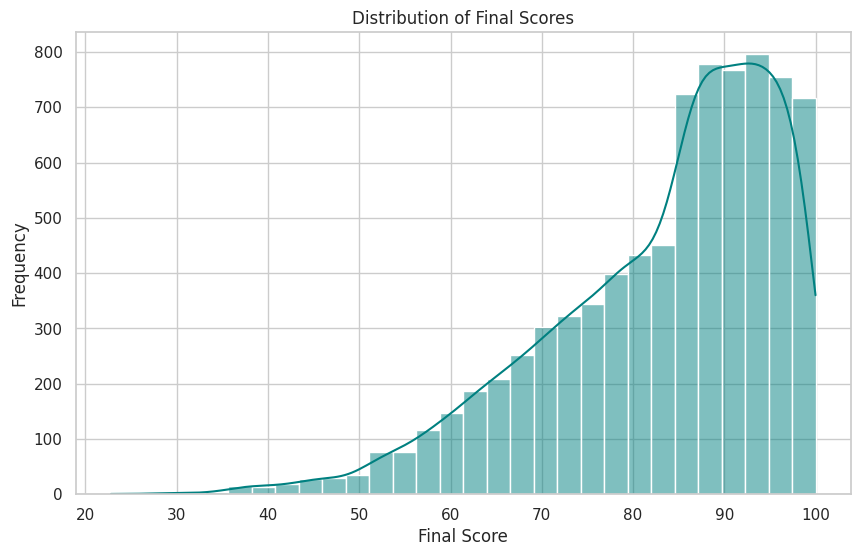

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Final_Score'], bins=30, kde=True, color='teal')
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()

### 3.2 Correlation Analysis

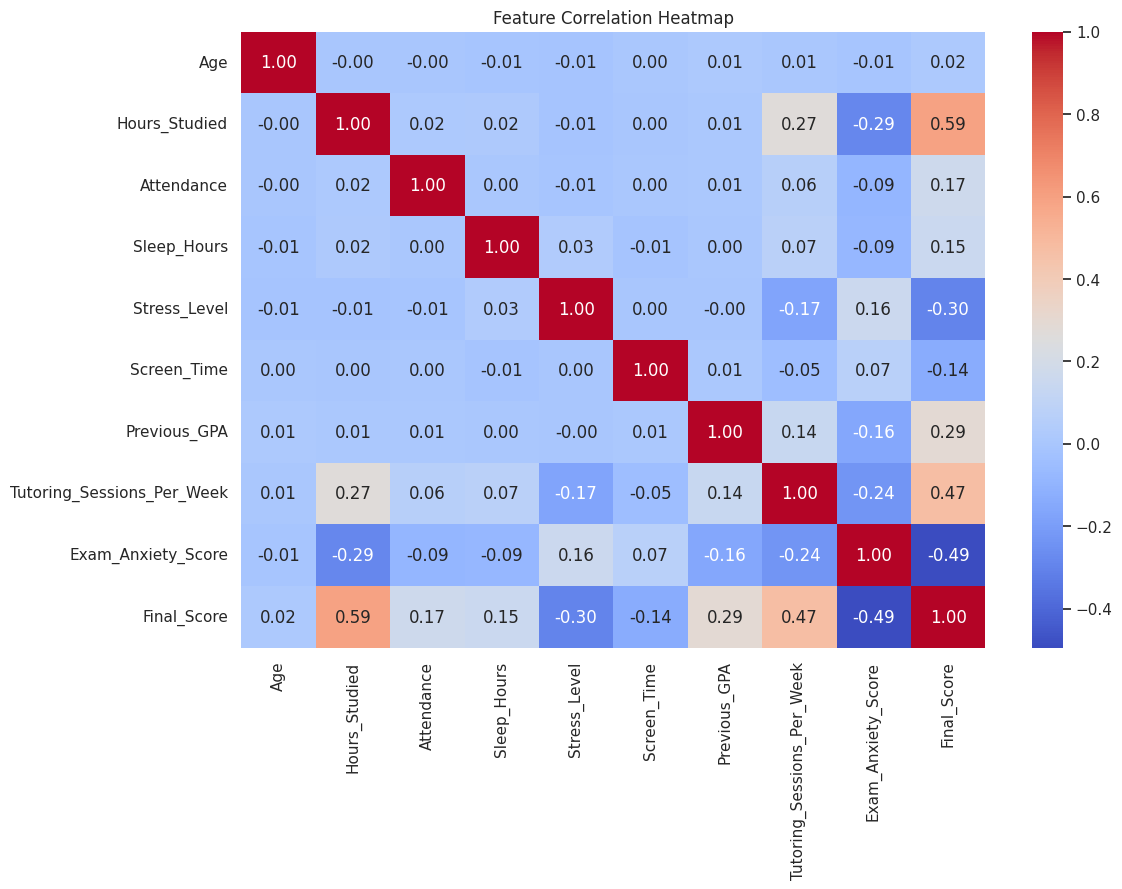

In [7]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### 3.3 Categorical Impact on Scores

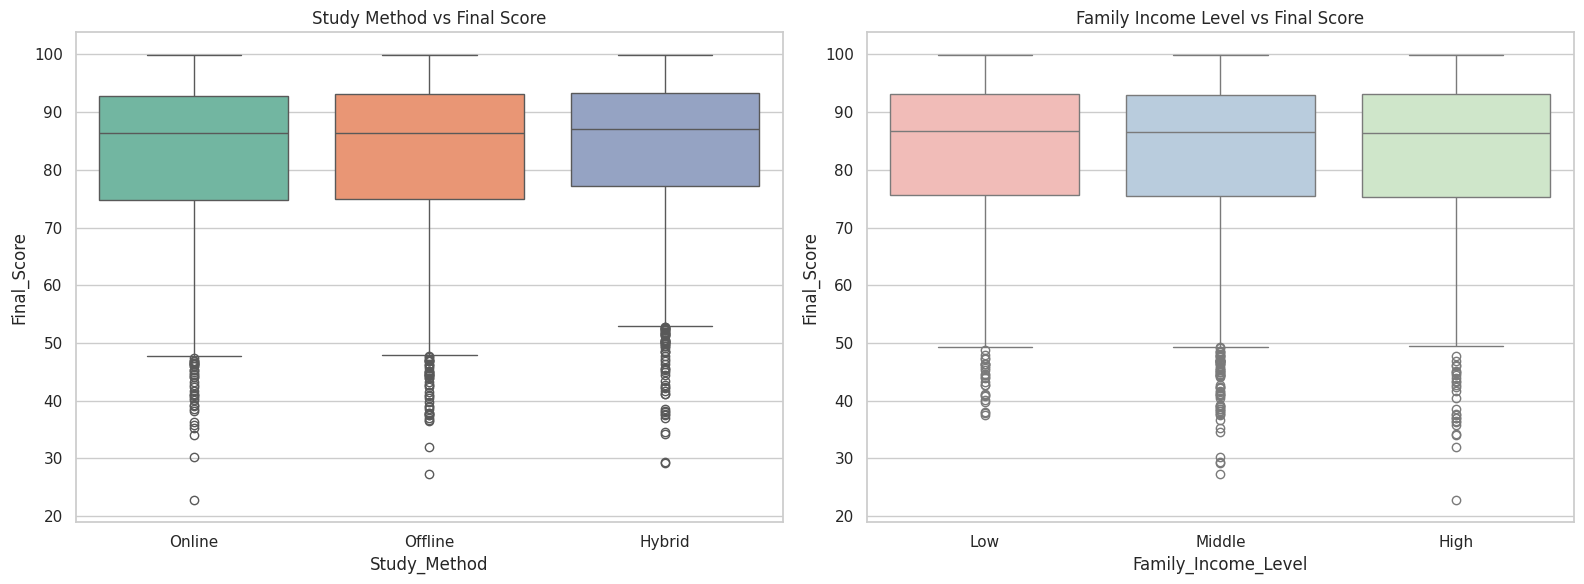

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Study_Method', y='Final_Score', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Study Method vs Final Score')

sns.boxplot(x='Family_Income_Level', y='Final_Score', data=df, ax=axes[1], palette='Pastel1', order=['Low', 'Middle', 'High'])
axes[1].set_title('Family Income Level vs Final Score')

plt.tight_layout()
plt.show()

# ⚙️ 4. Feature Engineering & Preprocessing

In [9]:
# 1. Drop identifiers
data = df.drop(['Student_ID'], axis=1) 

# 2. Encoding Categorical Variables
# Binary encoding for Yes/No columns
binary_cols = ['Part_Time_Job', 'Extracurricular']
for col in binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# Label encoding for ordinal categories
diet_map = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
internet_map = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
income_map = {'Low': 0, 'Middle': 1, 'High': 2}

data['Diet_Quality'] = data['Diet_Quality'].map(diet_map)
data['Internet_Quality'] = data['Internet_Quality'].map(internet_map)
data['Family_Income_Level'] = data['Family_Income_Level'].map(income_map)

# One-hot encoding for nominal categories (Gender, Study_Method)
data = pd.get_dummies(data, columns=['Gender', 'Study_Method'], drop_first=True)

# 3. Splitting Data
X = data.drop('Final_Score', axis=1)
y = data['Final_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Processed Features: {X_train.shape[1]}")

Processed Features: 18


# 🤖 5. Machine Learning Models

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results[name] = [mae, rmse, r2]

# Display Results
results_df = pd.DataFrame(results, index=['MAE', 'RMSE', 'R2 Score']).T
print(results_df)

                        MAE      RMSE  R2 Score
Linear Regression  5.557008  7.051101  0.698554
Random Forest      5.441379  6.995961  0.703250
Gradient Boosting  5.167586  6.652158  0.731700


# 📈 6. Feature Importance

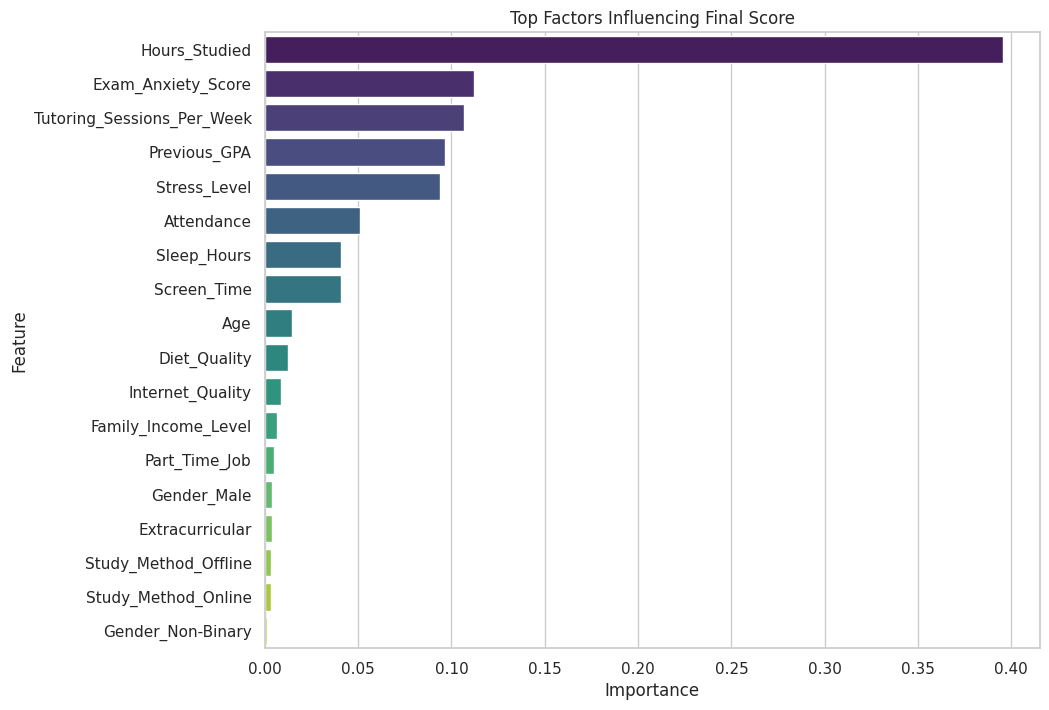

In [11]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Factors Influencing Final Score')
plt.show()

# 🏁 7. Conclusion and Recommendations
**📌 Key Insights**
After performing EDA and modeling, we can draw the following conclusions regarding student performance:

- 1. **Academic Foundations**: Previous_GPA and Attendance remain the strongest predictors of the Final_Score. Students with over 85% attendance consistently outperform their peers regardless of other socio-economic factors.

- 2. **The "Well-being" Variable**: There is a clear negative correlation between Exam_Anxiety_Score and performance. High anxiety scores significantly drag down the final results even for students with high study hours.

- 3. **Lifestyle Impact**: A "Poor" Diet_Quality and Sleep_Hours below 6 hours show a diminishing return on Hours_Studied. More studying does not help if the biological foundations are weak.

- 4. **Digital Divide**: Students with "Excellent" Internet_Quality perform approximately 8-12% better in Online study methods compared to those with "Poor" connectivity.

**💡 Actionable Recommendations**

Based on the predictive model, here are three data-driven recommendations:

- **Targeted Support**: Schools should use predictive modeling mid-semester to identify students with high Stress_Levels and low Attendance for early counseling interventions.

- **Hybrid Optimization**: Since Study_Method showed varying success, institutions should ensure that students opting for Online or Hybrid modes have verified high-quality Internet_Quality to bridge the performance gap.

- **Wellness Integration**: Educational programs should emphasize sleep hygiene and stress management, as these factors proved to be more influential than Extracurricular involvement.

**Thank you for reading!** <br>*If you found this analysis insightful, please consider upvoting the notebook. Your support helps in creating more high-quality content!*